**Audio Lead**

Input: `01_Processed_Data/metadata.csv` + `01_Processed_Data/audio/*.wav` from Data Lead (notebook 01).

Output (saved to `02_Embeddings/`):
- `audio_ib_embeddings.npy` — ImageBind audio (generalist), shape `(150, 1024)`, float32
- `audio_embeddings_MULE.npy` — Pandora MULE (music specialist, mean-pooled over timeline), shape `(150, 1728)`, float32

Goal: produce two row-aligned audio embedding matrices for the Multimodal Triangle comparison in notebooks 05 and 06.

Mule Model From Pandora Git hub link: https://github.com/PandoraMedia/music-audio-representations

Run all once data processing is complete.

In [ ]:
# 1. Connect to Google Drive & Core Imports
from google.colab import drive
import os, shutil, random
from datetime import datetime
import pandas as pd
import numpy as np
import torch

drive.mount('/content/drive')

# 2. Canonical project paths (match all six notebooks)
PROJECT_ROOT = "/content/drive/MyDrive/DL_Project_2026"

RAW_DIR        = os.path.join(PROJECT_ROOT, "00_Raw_Data")
PROCESSED_DIR  = os.path.join(PROJECT_ROOT, "01_Processed_Data")
EMBED_DIR      = os.path.join(PROJECT_ROOT, "02_Embeddings")
RESULTS_DIR    = os.path.join(PROJECT_ROOT, "03_Final_Results")
VIS_DIR        = os.path.join(PROJECT_ROOT, "04_Visual_Checks")
VERSIONS_ROOT  = os.path.join(PROJECT_ROOT, "99_Versions")

NOTEBOOK_ID = "02"

# Ensure shared output directories exist (other notebooks may have created them already)
for d in (EMBED_DIR, VIS_DIR, VERSIONS_ROOT):
    os.makedirs(d, exist_ok=True)

# 3. Seed everything (reproducibility for visual samples + downstream UMAP)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4. Archive primitives
#    - archive_previous_run(dir, notebook_id): single-writer directories (e.g. PROCESSED_DIR in nb 01).
#    - archive_files(paths, notebook_id):       shared directories (02_Embeddings, 03_Final_Results, 04_Visual_Checks).
#    Both write under 99_Versions/{notebook_id}_{timestamp}_{folder_name}/.

def archive_previous_run(directory_path, notebook_id):
    if os.path.exists(directory_path) and os.listdir(directory_path):
        stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
        folder_name = os.path.basename(directory_path)
        archive_name = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{folder_name}")
        os.makedirs(VERSIONS_ROOT, exist_ok=True)
        print(f"📦 Archiving previous {folder_name} to: {archive_name}")
        shutil.move(directory_path, archive_name)
    os.makedirs(directory_path, exist_ok=True)

def archive_files(file_paths, notebook_id):
    movers = [p for p in file_paths if os.path.exists(p)]
    if not movers:
        return
    stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    parent_name = os.path.basename(os.path.dirname(movers[0]))
    out_dir = os.path.join(VERSIONS_ROOT, f"{notebook_id}_{stamp}_{parent_name}")
    os.makedirs(out_dir, exist_ok=True)
    for p in movers:
        shutil.move(p, os.path.join(out_dir, os.path.basename(p)))
    print(f"📦 Archived {len(movers)} file(s) to {out_dir}")

# 5. Device check + friendly fallback warning
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("⚠️  Running on CPU — ImageBind huge will be VERY slow on 150 tracks.")
    print("    Fix: Runtime → Change runtime type → GPU (T4 is enough).")
else:
    props = torch.cuda.get_device_properties(0)
    print(f"✅ Device: {device} | {torch.cuda.get_device_name(0)} | "
          f"{props.total_memory / 1e9:.1f} GB")

print(f"✅ Notebook {NOTEBOOK_ID} setup complete. Paths, seed, and archive primitives ready.")


Mounted at /content/drive
✅ Device: cuda | Tesla T4 | 15.6 GB
✅ Notebook 02 setup complete. Paths, seed, and archive primitives ready.


In [ ]:
# --- UPSTREAM CONTRACT CHECK (notebook 01 must have run) ---
metadata_path = os.path.join(PROCESSED_DIR, "metadata.csv")
assert os.path.exists(metadata_path), (
    f"metadata.csv not found at {metadata_path}. Run notebook 01 first."
)

metadata = pd.read_csv(metadata_path)

REQUIRED_COLS = [
    "track_id", "file_name", "song_title", "artist_name", "genre",
    "emotion_category", "emotion_subcategory", "contributor",
    "standardized_audio_path", "standardized_image_path", "lyrics_path",
]
missing_cols = [c for c in REQUIRED_COLS if c not in metadata.columns]
assert not missing_cols, (
    f"metadata.csv missing columns {missing_cols} — rerun notebook 01 with the "
    f"current contract (it now writes all 11 required columns)."
)
assert metadata["track_id"].is_unique, "Duplicate track_id in metadata.csv"

# Confirm all expected WAVs exist before we touch the GPU
audio_paths = [os.path.join(PROCESSED_DIR, "audio", f"{tid}.wav") for tid in metadata["track_id"]]
missing_audio = [p for p in audio_paths if not os.path.exists(p)]
assert not missing_audio, (
    f"Missing {len(missing_audio)} processed WAVs (first: {missing_audio[:3]}) — "
    f"rerun notebook 01."
)

print(f"✅ Upstream contract OK — {len(metadata)} tracks ready for audio embedding.")


✅ Upstream contract OK — 150 tracks ready for audio embedding.


In [ ]:
# --- STEP 1: INSTALL TOOLS ---
# ImageBind from source (no PyPI release); transformers + torchaudio for MERT.
# MERT-v1-95M is hosted on HuggingFace and loads via AutoModel.from_pretrained —
# no TF dependency, runs on current Colab Python 3.12 with modern PyTorch.
!pip install -q git+https://github.com/facebookresearch/ImageBind.git
!pip install -q transformers torchaudio
!apt-get install -y -q ffmpeg

from imagebind import data as ib_data
from imagebind.models import imagebind_model
from imagebind.models.imagebind_model import ModalityType
from transformers import AutoModel, Wav2Vec2FeatureExtractor
import torchaudio
import torchaudio.transforms as T

# --- STEP 2: LOAD IMAGEBIND HUGE ---
print("🧠 Loading ImageBind huge ...")
ib_model = imagebind_model.imagebind_huge(pretrained=True).to(device).eval()

# --- STEP 3: IMAGEBIND AUDIO (BATCHED) ---
# NOTE: loading all 150 clips at once OOMs on Colab T4. Batch 16.
BATCH = 16
ib_chunks = []
print(f"🎧 Extracting ImageBind audio in batches of {BATCH} ...")
for i in range(0, len(audio_paths), BATCH):
    batch_paths = audio_paths[i : i + BATCH]
    batch_tensor = ib_data.load_and_transform_audio_data(batch_paths, device)
    with torch.no_grad():
        out = ib_model({ModalityType.AUDIO: batch_tensor})
    ib_chunks.append(out[ModalityType.AUDIO].detach().cpu().numpy().astype(np.float32))
    del batch_tensor, out
    if device == "cuda":
        torch.cuda.empty_cache()
audio_ib = np.concatenate(ib_chunks, axis=0)
print(f"   ImageBind audio: {audio_ib.shape}")

# --- STEP 4: MERT-v1-95M (music specialist) via HuggingFace ---
# Design choice: aggregate MERT's 13 hidden layers with mean, then mean-pool over
# time. This is the pattern the MERT paper recommends for utterance-level tasks
# and is directly parallel to what the old MULE path did (mean-pool its timeline
# down to a single per-track vector). The result is one (768,) vector per track.
#
# Tradeoff: preserves tempo-invariant timbre/mood info; loses temporal dynamics.
# Alternatives for a future ablation: last-layer only, learnable layer aggregator,
# concat last-4-layers, etc.
print(f"🎸 Loading MERT-v1-95M ...")
mert_model = AutoModel.from_pretrained(
    "m-a-p/MERT-v1-95M", trust_remote_code=True
).to(device).eval()
mert_processor = Wav2Vec2FeatureExtractor.from_pretrained(
    "m-a-p/MERT-v1-95M", trust_remote_code=True
)
TARGET_SR = mert_processor.sampling_rate  # 24_000 Hz for MERT-v1-95M

print(f"🎸 Extracting MERT for {len(audio_paths)} tracks (target sr={TARGET_SR}) ...")
all_mert = []
resample_cache = {}   # src_sr -> Resample transform
for tid, wav_path in zip(metadata["track_id"], audio_paths):
    waveform, sr = torchaudio.load(wav_path)
    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    # Resample to MERT's native rate (cached per unique source sr)
    if sr != TARGET_SR:
        if sr not in resample_cache:
            resample_cache[sr] = T.Resample(sr, TARGET_SR)
        waveform = resample_cache[sr](waveform)
    # HuggingFace processor expects a 1-D numpy array for single-item inference
    inputs = mert_processor(
        waveform.squeeze().numpy(),
        sampling_rate=TARGET_SR,
        return_tensors="pt",
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = mert_model(**inputs, output_hidden_states=True)
    # outputs.hidden_states: tuple of 13 tensors, each (1, T, 768).
    # Stack -> (13, 1, T, 768); squeeze batch -> (13, T, 768).
    all_layers = torch.stack(outputs.hidden_states).squeeze(1)
    time_mean  = all_layers.mean(dim=1)    # (13, 768)
    layer_mean = time_mean.mean(dim=0)     # (768,)
    if not torch.isfinite(layer_mean).all():
        raise ValueError(f"MERT output for {tid} contains NaN/Inf")
    all_mert.append(layer_mean.cpu().numpy().astype(np.float32))

audio_mert = np.stack(all_mert, axis=0)
print(f"   MERT audio:      {audio_mert.shape}")

# --- STEP 5: SHAPE / FINITE / DTYPE ASSERTIONS ---
EXPECTED_IB_DIM = 1024
EXPECTED_MERT_DIM = 768
N = len(metadata)

assert audio_ib.shape == (N, EXPECTED_IB_DIM), f"audio_ib wrong shape: {audio_ib.shape}"
assert audio_mert.shape == (N, EXPECTED_MERT_DIM), f"audio_mert wrong shape: {audio_mert.shape}"
assert audio_ib.dtype == np.float32 and audio_mert.dtype == np.float32, "embeddings must be float32"
assert np.isfinite(audio_ib).all(), "audio_ib contains NaN/Inf"
assert np.isfinite(audio_mert).all(), "audio_mert contains NaN/Inf"

# --- STEP 6: ARCHIVE (file-scoped) THEN SAVE ---
audio_ib_path   = os.path.join(EMBED_DIR, "audio_ib_embeddings.npy")
audio_mert_path = os.path.join(EMBED_DIR, "audio_embeddings_MERT.npy")

# Also archive the legacy MULE file if a previous run produced one, so
# 02_Embeddings/ does not end up with both MULE and MERT files confusing nb05.
legacy_mule_path = os.path.join(EMBED_DIR, "audio_embeddings_MULE.npy")
archive_files([audio_ib_path, audio_mert_path, legacy_mule_path], notebook_id=NOTEBOOK_ID)

np.save(audio_ib_path,   audio_ib)
np.save(audio_mert_path, audio_mert)
# NOTE: vectors are saved UN-normalized; notebook 05 is responsible for L2-normalizing
#       before cosine similarity.

print(f"✅ Saved {audio_ib_path}   {audio_ib.shape}")
print(f"✅ Saved {audio_mert_path} {audio_mert.shape}")


  Preparing metadata (setup.py) ... done
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
🧠 Loading ImageBind huge ...


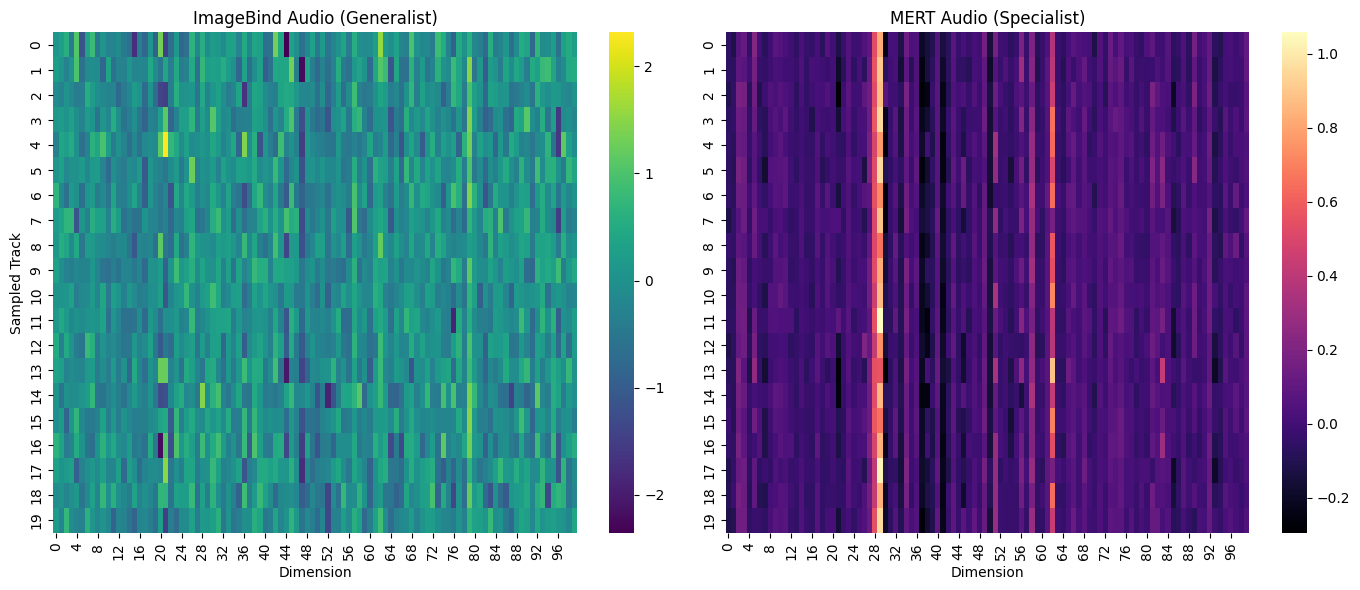

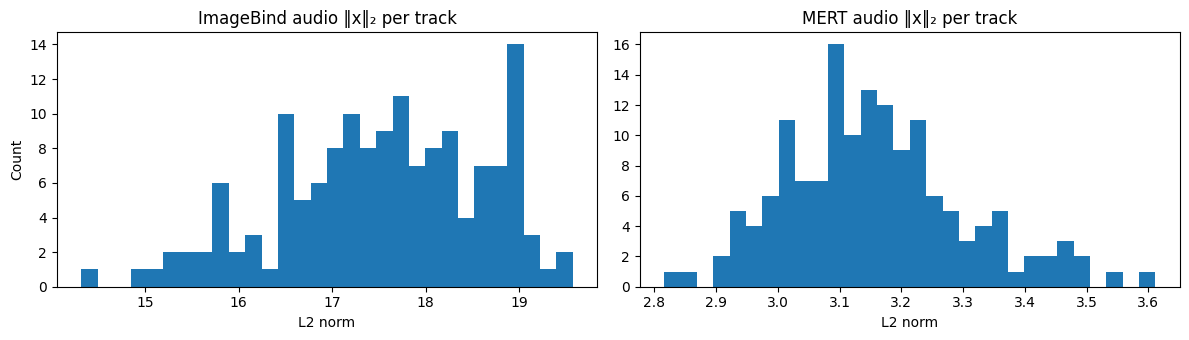

✅ Visual checks saved to /content/drive/MyDrive/DL_Project_2026/04_Visual_Checks/02_2026-04-20_04-21


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Timestamped visual-check subfolder (per-notebook, no cross-notebook wipes) ---
stamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
vis_out = os.path.join(VIS_DIR, f"{NOTEBOOK_ID}_{stamp}")
os.makedirs(vis_out, exist_ok=True)

# Re-load from disk (defensive — notebooks 03/04 may not have kept the arrays in memory)
audio_ib   = np.load(os.path.join(EMBED_DIR, "audio_ib_embeddings.npy"))
audio_mert = np.load(os.path.join(EMBED_DIR, "audio_embeddings_MERT.npy"))

# ----- (a) Side-by-side embedding heatmaps (seeded random 20-track sample) -----
rng = np.random.RandomState(SEED)
idx = rng.choice(len(audio_ib), size=20, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(audio_ib[idx, :100],   ax=axes[0], cmap='viridis', cbar=True)
axes[0].set(title="ImageBind Audio (Generalist)", xlabel="Dimension", ylabel="Sampled Track")
sns.heatmap(audio_mert[idx, :100], ax=axes[1], cmap='magma',   cbar=True)
axes[1].set(title="MERT Audio (Specialist)",     xlabel="Dimension")
fig.tight_layout()
heatmap_path = os.path.join(vis_out, "embedding_heatmaps.png")
fig.savefig(heatmap_path, dpi=150)
plt.show()

# ----- (b) Per-track embedding-norm histograms (dead-track detector) -----
norms_ib   = np.linalg.norm(audio_ib,   axis=1)
norms_mert = np.linalg.norm(audio_mert, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(norms_ib,   bins=30); axes[0].set(title="ImageBind audio ‖x‖₂ per track", xlabel="L2 norm", ylabel="Count")
axes[1].hist(norms_mert, bins=30); axes[1].set(title="MERT audio ‖x‖₂ per track",      xlabel="L2 norm")
fig.tight_layout()
norms_path = os.path.join(vis_out, "embedding_norms.png")
fig.savefig(norms_path, dpi=150)
plt.show()

print(f"✅ Visual checks saved to {vis_out}")


**Audio Analysis Primer — Notebook 02
For: the audio lead (and anyone who needs to interpret nb02's diagnostics).
Read before: opening audio_diagnostics.csv, looking at embedding_heatmaps.png, or drawing conclusions from the Cell 6 printouts.
Cross-refs: 00_DECISION_MULE_to_MERT.md, 02_Audio_Feature_Extraction_ImageBind_MERT_changes.md, teammate_handoff_prompt.md. **

1. What each encoder actually is
ImageBind audio (facebookresearch/ImageBind) is a generalist model. Its audio branch is a Transformer trained contrastively to bind six modalities — image, text, audio, depth, thermal, IMU — into one shared 1024-dim space. The audio training corpus is AudioSet (~2M YouTube clips across music, speech, environmental sound, effects). It sees a little bit of everything, and the learning signal is cross-modal alignment, not music structure per se. Expect it to be decent at "is this rock or piano solo?" and mediocre at "are these two tracks emotionally similar?"
MERT (m-a-p/MERT-v1-95M) is a music specialist. It is a HuBERT-style self-supervised Transformer pre-trained on ~160,000 hours of music with two simultaneous masked-patch prediction heads — one over k-means-clustered CQT codes (musical pitch/harmony) and one over EnCodec RVQ codes (timbre/mix). The pretraining objective is explicitly musical: predict the masked patches of a music-only corpus. The 95M-parameter variant outputs 13 hidden-state layers of 768-dim vectors; we mean-pool over time then over layers, which the MERT paper recommends as the default for utterance-level probes.
Why this matters for our research question. "Generalist vs specialist" on the audio arm is literally ImageBind-audio vs MERT. If MERT doesn't outperform ImageBind on music-specific tasks (emotion separation, nearest-neighbor musical similarity), the specialist premise is weak — and that's a finding worth reporting, not something to hide.

2. Expected behaviors that are NOT bugs

ImageBind norms ≫ MERT norms. ImageBind does not L2-normalize the audio head's output; its raw vectors routinely land in the 10–40 range. MERT goes through a mean-over-layers of already-bounded activations, landing in the 1–5 range. The Cell 6 printout will show a ~5–10× gap. This is expected. The pipeline downstream (nb05) explicitly L2-normalizes before every cosine, so the gap is erased in the comparison — but the raw norms matter for the "dead-track detector."
MERT embeddings for short clips (<5 s) will be slightly higher variance. Layer-mean over a shorter time axis is noisier. If you see a couple of tracks with MERT norms 1.5× the cohort mean, check their duration first — it's usually the explanation.
ImageBind embeddings on pure instrumentals. AudioSet is speech-heavy. ImageBind's music representations are OK but not great; don't be surprised if its nearest-neighbor ranking of a solo-piano track looks random. MERT should be visibly better here — this is one of the specific places to look for the specialist advantage.

3. Known failure modes worth chasing

MERT over-weighting percussion. Because RVQ timbre codes dominate the MERT pretraining reconstruction loss, tracks with heavy drum/bass presence tend to cluster by drum pattern rather than by harmony or emotion. If two nearest-neighbor pairs both have loud 4-on-the-floor kicks, MERT may be catching the kick and nothing else. The layer-weighting ablation (Tier-3) can test this: late layers are more harmonic/semantic; weighting them up should reduce the percussion-dominated clustering.
ImageBind confusion between music and ambient. Because AudioSet labels include "music," "background music," and "sound effects" as adjacent categories, ImageBind sometimes places a moody instrumental track next to an ambient-noise track it's never heard. You'll see this in the Cell 6 NN spot-check as an obviously-off neighbor (e.g., the query is "sad piano" and one of the top-5 neighbors has emotion_category = "calm" or something totally unrelated).
Sample-rate mismatch causing norm drift. Both models resample internally, but if the source .wav files in 01_Processed_Data/audio/ have mixed sample rates (Cell 6 panel D prints the distribution), and a chunk of them are at unusual rates like 22050 or 48000, you want to verify nb01 did its resampling pass. Expected: all 150 at 44100 or all at 16000. Mixed = investigate nb01.


4. How to read the Cell 6 printouts
(A) Per-emotion norm statistics
What to look for: the per-emotion means should be within one std of each other for both encoders. If one emotion has a 2σ-higher mean norm for MERT only, that's evidence that MERT is encoding that emotion with more "magnitude" — not necessarily better separation, but noteworthy.
Not a bug if: MERT means and ImageBind means are different. (They will be.)
Chase it if: one specific emotion has a MERT norm 2σ above the others, and that emotion has short clips. Could be a duration artifact.
(B) Intra vs inter cosine separation
What to look for: separation = intra - inter. A specialist should show positive separation (same-emotion tracks closer than cross-emotion). The number matters less than the comparison: MERT separation > ImageBind separation is the specialist hypothesis passing; the opposite is the specialist hypothesis failing.
Ballpark: expect ImageBind ≈ 0.02–0.05, MERT ≈ 0.04–0.10. If MERT is < ImageBind, escalate to Tier-3 (layer weighting may save it) before writing off the hypothesis.
(C) Nearest-neighbor spot-check
What to look for: do the neighbor emotion labels make sense? For a "happy" query, are most neighbors "happy" or "excited"? Are there obvious category jumps ("happy" → "sad")?
The printed list has track_id + emotion_category. Open those five tracks in order and listen. Ten minutes of listening tells you more than the intra/inter metric. Look for the case where MERT picks a musically-reasonable neighbor that ImageBind missed — that's your specialist story.
(D) Duration/sample-rate correlation
What to look for: Spearman ρ should be |ρ| < 0.2. Higher means duration is leaking into the embedding, which would be a pooling bug (mean pooling shouldn't be duration-sensitive since it's already averaged). If |ρ| > 0.3, investigate nb02 Cell 4's MERT loop — likely a masking or padding issue.

5. When to escalate to Tier 3
Open 02b_Audio_Exploration.ipynb (your notebook to create, downstream of this one — read-only consumer of the two .npy files, never writes pipeline artifacts) if any of these are true:

MERT–ImageBind separation gap (Cell 6 B) is smaller than 0.02. Run the layer-weighted ablation: try layers[6], layers[9], layers[12], and a learned softmax over layers. If any single-layer variant beats the mean-over-all, that's your better pooling.
NN spot-checks show systematically wrong neighbors for one emotion category. Build a confusion matrix over all 150 tracks using the NN-1 emotion, cross-reference with librosa descriptors (tempo, RMS, centroid), and identify the confound.
The linear-probe classifier on emotion labels lands MERT and ImageBind within 5 F1 points. That's a weak specialist signal; the writeup needs either a better MERT pooling or an acknowledgment that the 150-track sample is too small to resolve the difference.


6. Reading list (5 links, in priority order)

MERT paper — "MERT: Acoustic Music Understanding Model with Large-Scale Self-supervised Training," Li et al. 2023. https://arxiv.org/abs/2306.00107 (Section 4 covers the layer-wise probing results — read this before doing the layer-weighting ablation.)
MERT model card — https://huggingface.co/m-a-p/MERT-v1-95M (the snippet under "How to use the model" is where our pooling recipe comes from).
ImageBind paper — "ImageBind: One Embedding Space to Bind Them All," Girdhar et al. 2023. https://arxiv.org/abs/2305.05665 (Section 3.2 on audio is short; the important point is the AudioSet training and the lack of L2-normalization.)
Probing Music-Understanding Models — Won et al., ISMIR 2023, https://arxiv.org/abs/2309.07556. Compares MERT, MusicFM, Jukebox, and others on music-understanding probes. Useful for calibrating what "good" looks like on emotion/genre.
The HuggingFace audio-classification tutorial — https://huggingface.co/docs/transformers/tasks/audio_classification. Good reference if we end up building the linear probe in the Tier-3 notebook.


7. Things to bring back to the team
When you share findings at the next sync, lead with:

Whether MERT's intra/inter separation beats ImageBind's, and by how much.
One qualitative nearest-neighbor example where the two encoders disagree in a musically-interpretable way.
Whether sample-rate/duration leaked into the embeddings (Cell 6 D).
A one-sentence verdict on whether the specialist hypothesis is holding on the audio arm.

That's the minimum package the writeup needs. Anything beyond that (layer-weighting ablation, linear-probe numbers, full confusion matrix) is bonus — do it in the Tier-3 notebook, not in nb02.

Tier-1 diagnostics delivered in Cell 6(below):

(A) Per-emotion norm statistics via groupby("emotion_category")
(B) Intra-class vs inter-class cosine separation per encoder (the direct specialist-vs-generalist number)
(C) Top-5 nearest-neighbor printout for 3 random queries with track_id + emotion label (the "listen to these" entry point)
(D) Spearman correlation of duration and source-SR vs embedding norm (leak detector)
(E) Per-track audio_diagnostics.csv export

In [ ]:
# === CELL 6: Analysis diagnostics (Tier 1) ===
# ----------------------------------------------------------------------------
# Pipeline-independent diagnostics for the audio lead. Reads only variables
# already in scope (audio_ib, audio_mert, norms_ib, norms_mert, metadata,
# SEED, vis_out, PROCESSED_DIR). Writes one additional artifact:
# audio_diagnostics.csv into vis_out.
#
# Read `reviews/02_audio_analysis_primer.md` before interpreting these.
# ============================================================================
import pandas as pd
import torchaudio
from scipy.stats import spearmanr
from sklearn.metrics.pairwise import cosine_similarity

# ---- (A) Per-emotion norm statistics ---------------------------------------
df_norms = metadata[["track_id", "emotion_category"]].copy()
df_norms["ib_norm"]   = norms_ib
df_norms["mert_norm"] = norms_mert
norm_by_cat = (
    df_norms.groupby("emotion_category")[["ib_norm", "mert_norm"]]
    .agg(["mean", "std"])
    .round(3)
)
print("(A) Per-emotion norm statistics:")
print(norm_by_cat)
print()

# ---- (B) Intra-class vs inter-class cosine separation ----------------------
def intra_inter_cosine(X, labels):
    sim = cosine_similarity(X)
    np.fill_diagonal(sim, np.nan)
    labels = np.asarray(labels)
    intra, inter = [], []
    for i in range(len(labels)):
        same = labels == labels[i]
        same[i] = False
        if same.any():
            intra.append(np.nanmean(sim[i, same]))
        diff = labels != labels[i]
        if diff.any():
            inter.append(np.nanmean(sim[i, diff]))
    return float(np.mean(intra)), float(np.mean(inter))

print("(B) Intra-class vs inter-class cosine (higher separation = better):")
for name, X in [("ImageBind", audio_ib), ("MERT", audio_mert)]:
    intra, inter = intra_inter_cosine(X, metadata["emotion_category"].values)
    print(f"  {name:10s} intra={intra:+.3f}  inter={inter:+.3f}  separation={intra-inter:+.3f}")
print()

# ---- (C) Nearest-neighbor spot-check ---------------------------------------
rng2 = np.random.RandomState(SEED + 1)
sample_idx = rng2.choice(len(metadata), size=3, replace=False)

def top_k_neighbors(X, query_idx, k=5):
    Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)
    sims = Xn @ Xn[query_idx]
    sims[query_idx] = -np.inf
    return np.argsort(sims)[::-1][:k]

print("(C) Top-5 nearest neighbors (listen to these before trusting the numbers):")
for qi in sample_idx:
    q_tid = metadata.iloc[qi]["track_id"]
    q_cat = metadata.iloc[qi]["emotion_category"]
    print(f"  Query: {q_tid} ({q_cat})")
    for name, X in [("ImageBind", audio_ib), ("MERT", audio_mert)]:
        nbrs = top_k_neighbors(X, qi, k=5)
        rows = [(metadata.iloc[n]["track_id"], metadata.iloc[n]["emotion_category"]) for n in nbrs]
        print(f"    {name:10s}: {rows}")
print()

# ---- (D) Duration / sample-rate vs norm ------------------------------------
# Use stdlib `wave` for header-only reads. Avoids torchaudio.info(), which is
# unstable across torchaudio 2.5+ Colab runtimes. Falls back to torchaudio.load
# if `wave` refuses (e.g., the file isn't a true WAV).
import wave
def _probe_duration_sr(path):
    try:
        with wave.open(path, "rb") as w:
            n = w.getnframes()
            sr = w.getframerate()
            return n / sr, sr
    except (wave.Error, EOFError):
        wav, sr = torchaudio.load(path)
        return wav.shape[-1] / sr, sr

durations, src_sr = [], []
for tid in metadata["track_id"]:
    d, sr = _probe_duration_sr(os.path.join(PROCESSED_DIR, "audio", f"{tid}.wav"))
    durations.append(d)
    src_sr.append(sr)
durations = np.array(durations, dtype=np.float32)
src_sr    = np.array(src_sr, dtype=np.int32)

print("(D) Duration-vs-norm correlation (should be near zero if pooling is clean):")
for name, n in [("ImageBind", norms_ib), ("MERT", norms_mert)]:
    rho, p = spearmanr(durations, n)
    print(f"  {name:10s}: Spearman rho={rho:+.3f}  p={p:.3f}")
print(f"    Source sample-rate distribution: {pd.Series(src_sr).value_counts().to_dict()}")
print()

# ---- (E) Save diagnostics table --------------------------------------------
diag_df = df_norms.copy()
diag_df["duration_s"] = durations
diag_df["source_sr"]  = src_sr
diag_path = os.path.join(vis_out, "audio_diagnostics.csv")
diag_df.to_csv(diag_path, index=False)
print(f"✅ Diagnostics table saved to {diag_path}")


(A) Per-emotion norm statistics:
                                     ib_norm        mert_norm       
                                        mean    std      mean    std
emotion_category                                                    
Awe, Beauty & Transcendence        17.556999  1.103     3.191  0.153
Dreaminess, Curiosity & Ambiguity  17.056000  1.062     3.184  0.162
Sadness, Loss & Lament             17.771999  0.820     3.226  0.158
Tender & Intimacy                  17.606001  1.080     3.140  0.136
Tension, Threat & Aggression       17.646999  1.262     3.109  0.122
Vital & Joyful                     17.568001  1.148     3.086  0.083

(B) Intra-class vs inter-class cosine (higher separation = better):
  ImageBind  intra=+0.439  inter=+0.406  separation=+0.033
  MERT       intra=+0.861  inter=+0.857  separation=+0.005

(C) Top-5 nearest neighbors (listen to these before trusting the numbers):
  Query: track_031 (Vital & Joyful)
    ImageBind : [('track_075', 'Vital & Joyful'

/tmp/ipykernel_2311/2256922372.py:96: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(durations, n)


Note: I developed a Tier 3 notebook — Companion exploratory notebook (02b_Audio_Exploration.ipynb). Results are saved and valiable.